# 🎨 Color Analysis Predictor
## FARL Face Parsing + ResNet18 Feature Extraction

Predict your **Color Season** (Spring 🌸 / Summer ☀️ / Autumn 🍂 / Winter ❄️) from a face photo.

### Pipeline
| Step | Component | Task |
|---|---|---|
| 1 | **FARL / facer** | Face detection + skin & lip segmentation |
| 2 | **ResNet18** | Deep feature extraction from masked regions |
| 3 | **Color Distance** | Season classification by RGB palette proximity |
| 4 | **Visualization** | Heatmap · Scatter · Masked region |

---


In [ ]:
# ── 1. Install dependencies ──────────────────────────────────────────────────
!pip install pyfacer -q
!pip install torch torchvision -q
!pip install scikit-image -q
!pip install opencv-python-headless -q
print("✅ All packages installed!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 65.7 MB/s eta 0:00:00
✅ All packages installed!


In [ ]:
# ── 2. Imports ───────────────────────────────────────────────────────────────
import os, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import facer
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from PIL import Image
from collections import Counter
from google.colab import files

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️  Device : {device}")
print(f"🔥 PyTorch: {torch.__version__}")


🖥️  Device : cuda
🔥 PyTorch: 2.11.0+cu128


In [ ]:
# ── 3. ResNet18 Feature Extractor ────────────────────────────────────────────
class ResNet18FeatureExtractor(nn.Module):
    """Strips the FC head from ResNet18 → returns 512-d feature vector."""
    def __init__(self):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        self.eval()

    def forward(self, x):
        with torch.no_grad():
            return self.features(x).squeeze()

resnet_extractor = ResNet18FeatureExtractor().to(device)

resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

print("✅ ResNet18 feature extractor ready!")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 211MB/s]


✅ ResNet18 feature extractor ready!


## 📐 Core Functions
`get_rgb_codes` · `filter_lip_random` · `calc_dis` · `extract_resnet18_features`

In [ ]:
# ── 4. Core helper functions ─────────────────────────────────────────────────

# ---------- FARL face parser (shared init) ----------------------------------
_face_detector = None
_face_parser   = None

def _get_farl_models():
    global _face_detector, _face_parser
    if _face_detector is None:
        _face_detector = facer.face_detector('retinaface/mobilenet', device=device)
        _face_parser   = facer.face_parser('farl/lapa/448',          device=device)
    return _face_detector, _face_parser


def _parse_face(img_path):
    """Run FARL and return (img_rgb, seg_tensor_HxWxC)."""
    fd, fp = _get_farl_models()
    image  = facer.hwc2bchw(facer.read_hwc(img_path)).to(device)
    with torch.inference_mode():
        faces = fd(image)
    with torch.inference_mode():
        faces = fp(image, faces)
    seg_logits = faces['seg']['logits']
    seg_probs  = seg_logits.softmax(dim=1).cpu()
    tensor     = seg_probs.permute(0, 2, 3, 1).squeeze().numpy()
    sample     = cv2.imread(img_path)
    img_rgb    = cv2.cvtColor(sample, cv2.COLOR_BGR2RGB)
    return img_rgb, tensor


# ---------- Lip RGB extraction ----------------------------------------------
def get_rgb_codes(path):
    """Extract per-pixel RGB values inside the lip region."""
    img, tensor = _parse_face(path)
    llip        = tensor[:, :, 7]
    ulip        = tensor[:, :, 9]
    lips        = llip + ulip
    binary_mask = (lips >= 0.5).astype(int)
    indices     = np.argwhere(binary_mask)
    rgb_codes   = img[indices[:, 0], indices[:, 1], :]
    return rgb_codes


# ---------- Filter & sample lip pixels --------------------------------------
def filter_lip_random(rgb_codes, randomNum=40):
    """Filter realistic lip tones and take a random sample."""
    blue_condition    = (rgb_codes[:, 2] <= 227)
    red_condition     = (rgb_codes[:, 0] >= 97)
    filtered          = rgb_codes[blue_condition & red_condition]
    if len(filtered) == 0:
        filtered = rgb_codes
    n     = min(randomNum, len(filtered))
    idx   = np.random.randint(0, len(filtered), n)
    return filtered[idx]

# ----------  Classifier --------------------------------------
# ----------  Season distance classifier --------------------------------------
def calc_dis(rgb_codes):
    """Assign each sampled pixel to Spring / Summer / Autumn / Winter."""
    spring = np.array([[253,183,169],[247, 98, 77],[186, 33, 33]])
    summer = np.array([[243,184,202],[211,118,155],[147, 70,105]])
    autumn = np.array([[210,124,110],[155, 70, 60],[ 97, 16, 28]])
    winter = np.array([[237,223,227],[177, 47, 57],[ 98, 14, 37]])
    palettes = {'Spring': spring, 'Summer': summer,
                'Autumn': autumn, 'Winter': winter}
    res = []
    for px in rgb_codes:
        best_season = min(palettes,
            key=lambda s: min(np.linalg.norm(px - ref) for ref in palettes[s]))
        res.append(best_season)
    return res


# ---------- ResNet18 feature extraction from masked array -------------------
def extract_resnet18_features(masked_img_array):
    """Return 512-d ResNet18 feature vector for a masked numpy image."""
    pil  = Image.fromarray(masked_img_array.astype(np.uint8))
    t    = resnet_transform(pil).unsqueeze(0).to(device)
    feat = resnet_extractor(t)
    return feat.cpu().numpy()


print("✅ Helper functions defined!")


✅ Helper functions defined!


## 🔬 Skin Segmentation


In [ ]:
def analyze_skin(img_path):
    """
    Segment skin with FARL and produce three diagnostic plots.

    Returns
    -------
    img          : np.ndarray  H×W×3 original image (RGB)
    face_skin    : np.ndarray  H×W   skin probability map  [0..1]
    binary_mask  : np.ndarray  H×W   binary skin mask      {0,1}
    masked_image : np.ndarray  H×W×3 skin-only pixel region
    """
    img, tensor = _parse_face(img_path)

    # ── FARL skin channel (class index 1) ────────────────────────────────────
    face_skin   = tensor[:, :, 1]                        # float32 probability map
    binary_mask = (face_skin >= 0.5).astype(int)         # threshold → binary

    # ── Build masked image ────────────────────────────────────────────────────
    masked_image = np.zeros_like(img)
    masked_image[binary_mask == 1] = img[binary_mask == 1]

    # ── Figure with 3 subplots ────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.patch.set_facecolor('#0f0f0f')
    for ax in axes:
        ax.set_facecolor('#0f0f0f')
        for spine in ax.spines.values():
            spine.set_edgecolor('#333')

    # ── Visualisation 1 : face_skin probability heat-map ─────────────────────
    im = axes[0].imshow(face_skin, cmap='inferno', vmin=0, vmax=1)
    axes[0].set_title('Skin Probability Map\n(FARL · channel 1)',
                       color='white', fontsize=12, pad=10)
    axes[0].axis('off')
    cbar = plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
    cbar.ax.yaxis.set_tick_params(color='white')
    cbar.outline.set_edgecolor('white')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white', fontsize=8)

    # ── Visualisation 2 : scatter of non-zero mask pixels ────────────────────
    x, y = np.nonzero(binary_mask > 0)          # row, col indices
    axes[1].imshow(img)
    axes[1].scatter(y, x, c='#ff6b6b', s=0.4, alpha=0.35, linewidths=0)
    axes[1].set_title('Binary Mask Scatter\n(skin pixels highlighted)',
                       color='white', fontsize=12, pad=10)
    axes[1].axis('off')

    # ── Visualisation 3 : masked image ───────────────────────────────────────
    axes[2].imshow(masked_image)
    axes[2].set_title('Masked Skin Region\n(background removed)',
                       color='white', fontsize=12, pad=10)
    axes[2].axis('off')

    fig.suptitle('FARL · Face Skin Analysis', color='white',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    return img, face_skin, binary_mask, masked_image


print("✅ analyze_skin() defined!")


✅ analyze_skin() defined!


## 💋 Lip Segmentation
Same three-plot pattern applied to the lip region.

In [ ]:
# ── 6. FARL Lip Analysis  +  Three Visualisations ────────────────────────────

def analyze_lips(img_path):
    """
    Segment lips with FARL and produce three diagnostic plots.

    Returns
    -------
    lip_mask    : np.ndarray  H×W   binary lip mask {0,1}
    masked_lip  : np.ndarray  H×W×3 lip-only pixel region
    """
    img, tensor = _parse_face(img_path)

    llip      = tensor[:, :, 7]
    ulip      = tensor[:, :, 9]
    lips      = llip + ulip
    lip_mask  = (lips >= 0.5).astype(int)

    masked_lip = np.zeros_like(img)
    masked_lip[lip_mask == 1] = img[lip_mask == 1]

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.patch.set_facecolor('#0f0f0f')
    for ax in axes:
        ax.set_facecolor('#0f0f0f')

    # 1 – lip probability heat-map
    im = axes[0].imshow(lips, cmap='RdPu', vmin=0, vmax=1)
    axes[0].set_title('Lip Probability Map\n(upper + lower lip combined)',
                       color='white', fontsize=12, pad=10)
    axes[0].axis('off')
    cbar = plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
    cbar.ax.yaxis.set_tick_params(color='white')
    cbar.outline.set_edgecolor('white')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white', fontsize=8)

    # 2 – scatter overlay
    x, y = np.nonzero(lip_mask > 0)
    axes[1].imshow(img)
    axes[1].scatter(y, x, c='#cc5de8', s=0.8, alpha=0.5, linewidths=0)
    axes[1].set_title('Lip Mask Scatter\n(detected lip pixels)',
                       color='white', fontsize=12, pad=10)
    axes[1].axis('off')

    # 3 – masked lip region
    axes[2].imshow(masked_lip)
    axes[2].set_title('Isolated Lip Region\n(background removed)',
                       color='white', fontsize=12, pad=10)
    axes[2].axis('off')

    fig.suptitle('FARL · Lip Analysis', color='white',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    return lip_mask, masked_lip


print("✅ analyze_lips() defined!")


✅ analyze_lips() defined!


## 📤 Upload Image

In [ ]:
# ── 7. Upload your image ─────────────────────────────────────────────────────
print("📂  Please upload a face image (JPG / PNG)...")
uploaded   = files.upload()
img_path   = list(uploaded.keys())[0]

# Preview
orig       = cv2.imread(img_path)
orig_rgb   = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5), facecolor='#0f0f0f')
ax = plt.gca(); ax.set_facecolor('#0f0f0f')
plt.imshow(orig_rgb)
plt.title('Uploaded Image', color='white', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()
print(f"✅ Loaded: {img_path}  |  size: {orig.shape[1]}×{orig.shape[0]} px")


📂  Please upload a face image (JPG / PNG)...


## ▶️ Run Pipeline

In [ ]:
# ── 8. Run Skin Analysis ─────────────────────────────────────────────────────
print("\n🔍  Segmenting skin with FARL …")
img, face_skin, skin_mask, masked_skin = analyze_skin(img_path)
print("✅  Skin analysis complete!")


In [ ]:
# ── 9. Run Lip Analysis ──────────────────────────────────────────────────────
print("\n💋  Segmenting lips with FARL …")
lip_mask, masked_lip = analyze_lips(img_path)
print("✅  Lip analysis complete!")


In [ ]:
# ── 10. ResNet18 Feature Extraction ─────────────────────────────────────────
print("\n🧠  Extracting ResNet18 features from skin & lip regions …")

skin_feat = extract_resnet18_features(masked_skin)   # 512-d
lip_feat  = extract_resnet18_features(masked_lip)    # 512-d
combined_feat = np.concatenate([skin_feat, lip_feat])  # 1024-d

# Mean RGB from non-black pixels (for colour display)
def mean_rgb(masked_array):
    valid = masked_array[np.any(masked_array > 0, axis=2)]
    return valid.mean(axis=0) if len(valid) > 0 else np.zeros(3)

skin_mean = mean_rgb(masked_skin)
lip_mean  = mean_rgb(masked_lip)

print(f"  Skin mean RGB  : R={skin_mean[0]:.1f}  G={skin_mean[1]:.1f}  B={skin_mean[2]:.1f}")
print(f"  Lip  mean RGB  : R={lip_mean[0]:.1f}  G={lip_mean[1]:.1f}  B={lip_mean[2]:.1f}")
print(f"  ResNet18 feature vector norm (combined): {np.linalg.norm(combined_feat):.2f}")


## 🎨 Season Prediction

In [ ]:
# ── 11. Colour-Season Prediction ─────────────────────────────────────────────
print("\n🎨  Running colour season analysis …")
np.random.seed(42)

rgb_codes      = get_rgb_codes(img_path)
filtered_codes = filter_lip_random(rgb_codes, randomNum=60)
season_results = calc_dis(filtered_codes)

counter           = Counter(season_results)
dominant_season   = counter.most_common(1)[0][0]
dominant_count    = counter.most_common(1)[0][1]
total             = len(season_results)

print(f"\n  Distribution : {dict(counter)}")
print(f"  Dominant     : {dominant_season}  ({dominant_count}/{total} samples)")


## 📊 Batik Color Recommendation

In [ ]:
# ── 12. Final Results Dashboard ──────────────────────────────────────────────

# ── Season meta-data ─────────────────────────────────────────────────────────
SEASON_INFO = {
    'Spring': {
        'emoji'  : '🌸',
        'desc'   : 'Warm & Light — You glow in warm, golden tones!',
        'colors' : ['Warm Peach', 'Coral', 'Golden Red'],
        'palette': ['#FDB7A9', '#F7624D', '#BA2121'],
        'bg'     : '#fff0ee',
    },
    'Summer': {
        'emoji'  : '☀️',
        'desc'   : 'Cool & Light — You shine in soft, cool pastels!',
        'colors' : ['Soft Pink', 'Mauve', 'Berry'],
        'palette': ['#F3B8CA', '#D3769B', '#93466B'],
        'bg'     : '#fff0f8',
    },
    'Autumn': {
        'emoji'  : '🍂',
        'desc'   : 'Warm & Deep — You radiate in earthy, warm tones!',
        'colors' : ['Terracotta', 'Brick', 'Deep Wine'],
        'palette': ['#D27C6E', '#9B463C', '#61101C'],
        'bg'     : '#fff4ee',
    },
    'Winter': {
        'emoji'  : '❄️',
        'desc'   : 'Cool & Deep — You dazzle in bold, cool contrasts!',
        'colors' : ['Icy Pink', 'True Red', 'Deep Burgundy'],
        'palette': ['#EDDFE3', '#B12F39', '#620E25'],
        'bg'     : '#f0f0ff',
    },
}

info = SEASON_INFO[dominant_season]

# ── Dashboard layout ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 12), facecolor='#111')

gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.32)

axes_orig   = fig.add_subplot(gs[0, 0])
axes_skin   = fig.add_subplot(gs[0, 1])
axes_lip    = fig.add_subplot(gs[0, 2])
axes_hmap   = fig.add_subplot(gs[0, 3])
axes_pie    = fig.add_subplot(gs[1, 0])
axes_pal    = fig.add_subplot(gs[1, 1])
axes_rgb    = fig.add_subplot(gs[1, 2])
axes_feat   = fig.add_subplot(gs[1, 3])

for ax in fig.axes:
    ax.set_facecolor('#1a1a1a')
    for sp in ax.spines.values():
        sp.set_edgecolor('#333')

# 1 – original
axes_orig.imshow(orig_rgb)
axes_orig.set_title('Original Image', color='white', fontsize=11)
axes_orig.axis('off')

# 2 – masked skin
axes_skin.imshow(masked_skin)
axes_skin.set_title('Skin Region (FARL)', color='white', fontsize=11)
axes_skin.axis('off')

# 3 – masked lip
axes_lip.imshow(masked_lip)
axes_lip.set_title('Lip Region (FARL)', color='white', fontsize=11)
axes_lip.axis('off')

# 4 – skin probability heatmap (compact repeat)
im = axes_hmap.imshow(face_skin, cmap='inferno', vmin=0, vmax=1)
axes_hmap.set_title('Skin Prob. Map', color='white', fontsize=11)
axes_hmap.axis('off')
plt.colorbar(im, ax=axes_hmap, fraction=0.046, pad=0.04).ax.tick_params(colors='white', labelsize=7)

# 5 – season distribution pie
season_hex = {'Spring': '#FDB7A9', 'Summer': '#D3769B',
              'Autumn': '#9B463C', 'Winter': '#B12F39'}
labels_pie  = list(counter.keys())
sizes_pie   = list(counter.values())
colors_pie  = [season_hex.get(l, '#888') for l in labels_pie]
wedges, texts, autotexts = axes_pie.pie(
    sizes_pie, labels=labels_pie, colors=colors_pie,
    autopct='%1.0f%%', startangle=90,
    textprops={'color': 'white', 'fontsize': 9},
    wedgeprops={'edgecolor': '#111', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(8)
axes_pie.set_title('Season Distribution', color='white', fontsize=11)

# 6 – colour palette swatches
for idx, (hex_col, col_name) in enumerate(zip(info['palette'], info['colors'])):
    rect = plt.Rectangle((idx/3, 0.15), 1/3, 0.7,
                          facecolor=hex_col, edgecolor='#111', linewidth=2)
    axes_pal.add_patch(rect)
    axes_pal.text(idx/3 + 1/6, 0.05, col_name,
                  ha='center', va='top', fontsize=8.5, color='white')
    axes_pal.text(idx/3 + 1/6, 0.92, hex_col,
                  ha='center', va='bottom', fontsize=7, color='#aaa')
axes_pal.set_xlim(0, 1); axes_pal.set_ylim(0, 1)
axes_pal.axis('off')
axes_pal.set_title('Seasonal Colour Palette', color='white', fontsize=11)

# 7 – mean RGB bar chart
x_pos  = np.arange(3)
w      = 0.35
ch_col = ['#ff6b6b', '#51cf66', '#4dabf7']
bars1  = axes_rgb.bar(x_pos - w/2, skin_mean, w,
                      color=ch_col, alpha=0.9, label='Skin', edgecolor='#111')
bars2  = axes_rgb.bar(x_pos + w/2, lip_mean,  w,
                      color=ch_col, alpha=0.5, label='Lip',
                      edgecolor='white', linewidth=0.8)
axes_rgb.set_xticks(x_pos); axes_rgb.set_xticklabels(['R','G','B'], color='white')
axes_rgb.set_ylim(0, 255)
axes_rgb.set_title('Mean RGB  (Skin vs Lip)', color='white', fontsize=11)
axes_rgb.tick_params(colors='white', labelsize=9)
axes_rgb.set_ylabel('Value', color='white', fontsize=9)
axes_rgb.legend(fontsize=8, facecolor='#222', labelcolor='white', edgecolor='#444')
for bar_set in [bars1, bars2]:
    for b in bar_set:
        h = b.get_height()
        axes_rgb.text(b.get_x()+b.get_width()/2, h+3, f'{h:.0f}',
                      ha='center', va='bottom', color='white', fontsize=7)

# 8 – ResNet18 feature vector magnitude (per-channel abs-mean)
skin_feat_ch = np.abs(skin_feat[:32])    # show first 32 dims
lip_feat_ch  = np.abs(lip_feat[:32])
feat_x       = np.arange(32)
axes_feat.fill_between(feat_x, skin_feat_ch, alpha=0.6,
                       color='#74c0fc', label='Skin feat.')
axes_feat.fill_between(feat_x, lip_feat_ch,  alpha=0.6,
                       color='#f783ac', label='Lip feat.')
axes_feat.set_title('ResNet18 Feature Activation\n(first 32 dims)', color='white', fontsize=11)
axes_feat.tick_params(colors='white', labelsize=7)
axes_feat.set_xlabel('Feature dim', color='white', fontsize=8)
axes_feat.legend(fontsize=8, facecolor='#222', labelcolor='white', edgecolor='#444')
axes_feat.set_xlim(0, 31)

# ── Super-title ───────────────────────────────────────────────────────────────
fig.suptitle(
    f"{info['emoji']}  Colour Season: {dominant_season.upper()}  {info['emoji']}\n"
    f"{info['desc']}\n"
    f"Confidence: {dominant_count}/{total} lip samples  |  "
    f"ResNet18 feature norm: {np.linalg.norm(combined_feat):.2f}",
    color='white', fontsize=14, fontweight='bold', y=1.03
)

plt.savefig('color_analysis_result.png', dpi=150, bbox_inches='tight',
            facecolor='#111', edgecolor='none')
plt.show()
print("📸  Dashboard saved as  color_analysis_result.png")


In [ ]:
# ── 13. Console Summary ──────────────────────────────────────────────────────
info = SEASON_INFO[dominant_season]

print()
print("╔══════════════════════════════════════════════════════╗")
print(f"║   {info['emoji']}  YOUR COLOUR SEASON : {dominant_season.upper():<20}   {info['emoji']}  ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  {info['desc']:<52}║")
print("║                                                      ║")
print("║  ✨  Signature Colours:                              ║")
for c in info['colors']:
    print(f"║      • {c:<46}║")
print("║                                                      ║")
print(f"║  📊  Lip samples analysed : {total:<5}                      ║")
print(f"║  🏆  Dominant season votes: {dominant_count}/{total:<4}                     ║")
print(f"║  🧠  ResNet18 feat. norm  : {np.linalg.norm(combined_feat):<8.2f}                  ║")
print(f"║  🎨  Skin mean RGB        : ({skin_mean[0]:.0f}, {skin_mean[1]:.0f}, {skin_mean[2]:.0f})                  ║")
print(f"║  💄  Lip  mean RGB        : ({lip_mean[0]:.0f}, {lip_mean[1]:.0f}, {lip_mean[2]:.0f})                  ║")
print("╚══════════════════════════════════════════════════════╝")


## 📊 Batik Motif Recommendation

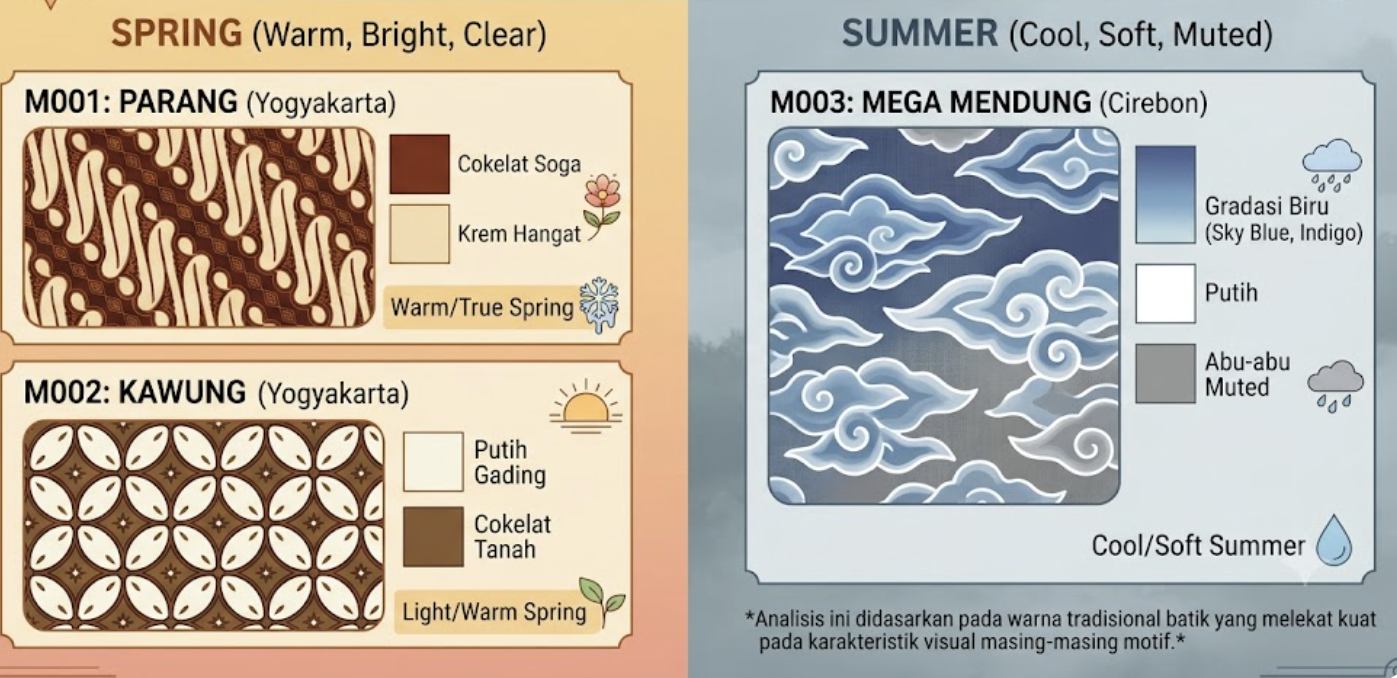